# Fitting a GLM-HMM with Dynamax
Written by Philippa Johnson 

PYTHON SETUP: See SETUP_NOTEBOOK_ENV.md for instructions.


We are using the Rausch and Zehetleitner [(2016)](https://www.frontiersin.org/journals/psychology/articles/10.3389/fpsyg.2016.00591/full) dataset from [The Confidence Database](https://osf.io/s46pr/)

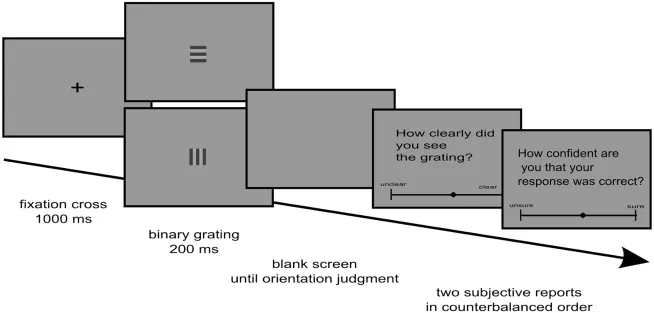

From the paper: The target stimulus was either a circle or a square textured with a binary grating. The lighter and darker luminance of the grating varied randomly across trials, resulting in six different levels of luminance contrasts: 0% (uniform stimulus luminance at 38.2 cd/m2), 2.2% (39.0 vs. 37.3 cd/m2), 3.9% (39.5/36.5 cd/m2), 5.0% (40.0 vs. 36.2 cd/m2), 5.5% (40.2 vs. 36.0 cd/m2), and 6.9% (41.1 vs. 35.8 cd/m2). The orientation of the texture was either horizontal or vertical and randomly varied across trials. The target stimulus was always presented at fixation in front of a gray background. Participants responded to the orientation task by pressing “A” or “S” on the keyboard with their left hands.

Steps in this notebook:
- preprocess the data
- run cross-validation for model selection
- fit the final model and inspect outputs

This notebook uses the [Dynamax package](https://probml.github.io/dynamax/index.html). Dynamax is a library for probabilistic state space models (SSMs). It has code for inference (state estimation) and learning (parameter estimation) in a variety of SSMs,

In [1]:
import copy
from pathlib import Path

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dynamax.hidden_markov_model import LogisticRegressionHMM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

sns.set_context('talk')
np.random.seed(0)
key = jr.PRNGKey(0)

## 1) Load and preprocess the data

This cell applies the core preprocessing steps for the dataset.

**Task:** After running, inspect the columns and make sure you understand all the information in the dataset - what do the columns refer to? What do different values mean?

**Task:** Make some simple plots to visualise the data - psychometric curve, chronometric curve... Do participants show a choice history bias?

In [2]:
data = pd.read_csv(Path('.') / 'data' / 'data_Rausch_2016.csv')

# preprocess data
data = data[data['Training'] == 0] # drop practice trials
data['Stimulus'] = data['Stimulus'].replace({1: 0, 2: 1}) # recode stimuli and response and 0 (left) and 1 (right)
data['Response'] = data['Response'].replace({1: 0, 2: 1})
data['prev_choice'] = data.groupby('Subj_idx')['Response'].shift() # create previous choice column within subject
data['block_breaks'] = ((data.index + 1) % 42 == 0).astype(int) # create block column
data['block'] = data.groupby('Subj_idx')['block_breaks'].cumsum()
data['block'] = data.groupby('Subj_idx')['block'].shift().replace(np.nan, 0)
data['contrast_n'] = data['contrast'] / data['contrast'].max() # rescale contrast
data['sensory_evidence'] = np.where(data['Stimulus'] == 1, data['contrast_n'], -data['contrast_n']) # create signed sensory evidence column

# drop first trial of each subject where prev_choice is NaN
data = data.groupby('Subj_idx').apply(lambda group: group.iloc[1:]).reset_index()

print('N rows:', len(data))
print('N subjects:', data['Subj_idx'].nunique())
display(data.head())

N rows: 7540
N subjects: 20


,Subj_idx,level_1,Stimulus,Response,Confidence,Visibility,RT_dec,contrast,Accuracy,Training,ScaleOrder,prev_choice,block_breaks,block,contrast_n,sensory_evidence
0,1,43,0,1,-3.6774,-1.9751,2.1639,2.2,0,0,Visibility first,1.0,0,0.0,0.318841,-0.318841
1,1,44,0,0,4.3622,4.8350,1.9539,5.0,1,0,Visibility first,1.0,0,0.0,0.724638,-0.724638
2,1,45,1,1,-4.6232,-3.2045,2.0073,0.0,1,0,Visibility first,0.0,0,0.0,0.000000,0.000000
3,1,46,1,1,-0.3673,-0.4619,2.0652,3.9,1,0,Visibility first,1.0,0,0.0,0.565217,0.565217
4,1,47,0,1,-1.9751,-0.6510,2.4338,0.0,0,0,Visibility first,1.0,0,0.0,0.000000,-0.000000


## 2) Define helper functions

The next cell defines the core helper functions used in this walkthrough (cross-validation + fitting + basic state extraction).

In [3]:
from glmhmm_helpers import (
    calculate_baseline_test_ll,
    calculate_cv_bit_trial,
    crossvalidate_HMM_dynamax,
    crossvalidate_glm_baseline,
    estimate_emission_params,
    fit_HMM_dynamax,
    fit_glm_baseline,
    get_state_order_dynamax,
    get_state_params_dynamax,
    get_state_probs_dynamax,
    plot_state_psychometric_curves,
    relabel_inferred_states_dynamax,
    reshape_priors,
    set_HMM_params,
)

## 3) Define model specifications and variants

In this cell we define the shared model settings and the model variants to compare.

We include a **1-state GLM baseline** (same logistic-regression style used for priors) plus multi-state HMM variants with and without `prev_choice`.

**Task**: Can you think of other models you could compare? Different covariates? Have a go at implementing them.

In [4]:
HMM_default_specs = {
    'n_iters': 1000,
    'EM_tol': 1e-6,
    'n_inits': 2,
    'n_states': 2,
    'trial_start': 0,
    'trial_stop': 1000,
    'outputs': ['Response'],
    'covariates_emissions': ['sensory_evidence', 'prev_choice'],
    'n_folds': 5,
}

# model variants to compare
model_variants_dict = {
    '1state_with_prev': {
        'model_type': 'glm',
        'covariates_emissions': ['sensory_evidence', 'prev_choice'],
    },
    '2state_with_prev': {
        'model_type': 'hmm',
        'n_states': 2,
        'covariates_emissions': ['sensory_evidence', 'prev_choice'],
    },
    '2state_no_prev': {
        'model_type': 'hmm',
        'n_states': 2,
        'covariates_emissions': ['sensory_evidence'],
    },
    '3state_with_prev': {
        'model_type': 'hmm',
        'n_states': 3,
        'covariates_emissions': ['sensory_evidence', 'prev_choice'],
    },
}

display(pd.DataFrame({
    'model': list(model_variants_dict.keys()),
    'model_type': [model_variants_dict[m]['model_type'] for m in model_variants_dict],
    'n_states': [model_variants_dict[m].get('n_states', 1) for m in model_variants_dict],
    'covariates_emissions': [str(model_variants_dict[m]['covariates_emissions']) for m in model_variants_dict],
}))

,model,model_type,n_states,covariates_emissions
0,1state_with_prev,glm,1,"['sensory_evidence', 'prev_choice']"
1,2state_with_prev,hmm,2,"['sensory_evidence', 'prev_choice']"
2,2state_no_prev,hmm,2,['sensory_evidence']
3,3state_with_prev,hmm,3,"['sensory_evidence', 'prev_choice']"


## 4) Run a simple global fit first

Before selecting one participant, we fit 'global models', which means we use data from every subject concatenated. This provides sensible starting values for the individual subject fits. Sometimes referred to as a 'poor man's heirarchical fit', this is a substitute for a full heirarchical fit. As far as I know, there are no Python packages that can do the full version, but there are packages available in R.

To keep this simple, we use one initialization (`n_inits = 1`) for each model in `model_variants_dict`. **N.B. Expectation-maximisation does not guarantee that you will find a global optimum; 1 initialisation is insufficient!** I generally use 20, but it takes 20x longer to run, of course. 

The plot shows the log-likelihood over the course of model fitting. But bear in mind that you should not interpret the winning model. Why not?

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:09&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:07&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:13&lt;00:00]</div>

,model,global_final_log_prob,model_type
0,1state_with_prev,-3070.298331,glm
1,2state_with_prev,-3021.35,hmm
2,2state_no_prev,-3008.998,hmm
3,3state_with_prev,-2992.8794,hmm


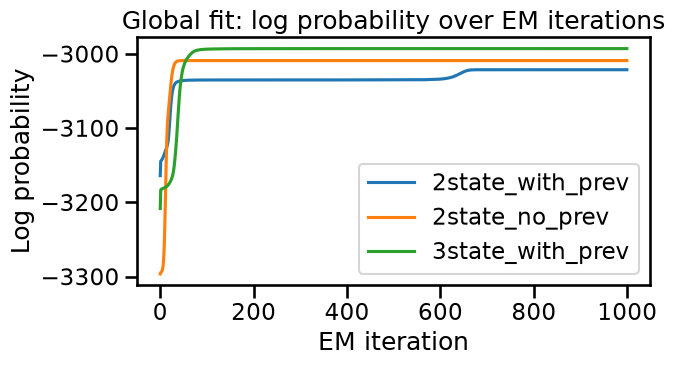

In [5]:
global_fit_params = {}
global_fit_final_ll = {}
global_fit_lps = {}

for model_i, params_dict in model_variants_dict.items():
    model_type = params_dict.get('model_type', 'hmm')
    model_params = {k: v for k, v in params_dict.items() if k != 'model_type'}
    HMM_specs = set_HMM_params(HMM_default_specs, **model_params)

    if model_type == 'glm':
        glm, ll = fit_glm_baseline(data, HMM_specs)
        global_fit_params[model_i] = glm
        global_fit_final_ll[model_i] = ll
        global_fit_lps[model_i] = None
        continue

    HMM_specs = set_HMM_params(HMM_specs, n_inits=1)  # one start value for global fit

    glm_weights = estimate_emission_params(data, HMM_specs) # estimate starting values for fits from normal GLM
    emission_prior_weights = reshape_priors(glm_weights, HMM_specs['n_states'])

    HMM_inits, HMM_params_inits, HMM_inits_lps = fit_HMM_dynamax(
        data,
        HMM_specs,
        emission_prior_weights,
        emission_prior_sigma=0.2,
        key=key,
    )

    best_model_ind = np.argmax([lps[-1] for lps in HMM_inits_lps])
    global_fit_params[model_i] = HMM_params_inits[best_model_ind]
    global_fit_final_ll[model_i] = HMM_inits_lps[best_model_ind][-1]
    global_fit_lps[model_i] = HMM_inits_lps[best_model_ind]

display(pd.DataFrame({
    'model': list(global_fit_final_ll.keys()),
    'global_final_log_prob': list(global_fit_final_ll.values()),
    'model_type': [model_variants_dict[m]['model_type'] for m in global_fit_final_ll.keys()],
}))

# plot global-fit log-probability trajectories over EM iterations
plt.figure(figsize=(7, 4))
for model_i, lps in global_fit_lps.items():
    if lps is None:
        continue
    plt.plot(lps, label=model_i)
plt.xlabel('EM iteration')
plt.ylabel('Log probability')
plt.title('Global fit: log probability over EM iterations')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Keep one subject only

To keep this notebook focused, we only use data from **one subject** in the dataset. Feel free to select a subject of your choice.


In [6]:
one_subject = np.sort(data['Subj_idx'].unique())[0]
session_df = data[data['Subj_idx'] == one_subject].copy()

print('Subject:', one_subject)
print('Trials in session_df:', len(session_df))
display(session_df.groupby('block').size().head())

Subject: 1
Trials in session_df: 377


block
0.0    41
1.0    42
2.0    42
3.0    42
4.0    42
dtype: int64

## 6) Cross-validation over a small model set

We compare the 1-state GLM baseline and the HMM variants using GroupKFold over `block`.

Here we use **cv bits/trial** as the performance metric:

- For each fold, we compute held-out log-likelihood of the model and subtract a baseline log-likelihood (`ll0`) from a simple class-frequency model.
- We divide by the number of held-out trials and convert from nats to bits (`/ log(2)`). Nats are information units based on natural logarithms, while bits are based on log base 2, so dividing by `log(2)` just converts the same quantity into a more intuitive unit (bits).

A **simple class-frequency model** means: estimate response probabilities from class proportions in the training set, then predict those same probabilities for every validation trial (ignoring all covariates and states).

For binary responses, if the training set has proportion `p` of response 1, the baseline predicts `p` for response 1 (and `1-p` for response 0) on every trial.

So `cv_bits_per_trial` tells us how many extra bits of predictive information the model gives per trial over this baseline on unseen data. Higher values mean better generalization, which is why this is useful for cross-validation model comparison.

In [7]:
cv_bits_fold = {}
for model_i, params_dict in model_variants_dict.items():
    print(f'Running CV for model: {model_i}')
    model_type = params_dict.get('model_type', 'hmm')
    model_params = {k: v for k, v in params_dict.items() if k != 'model_type'}
    HMM_specs = set_HMM_params(HMM_default_specs, **model_params)

    if model_type == 'glm':
        cv_bits_fold[model_i] = crossvalidate_glm_baseline(session_df, HMM_specs)
        print(f"Completed {model_i}: mean CV bits/trial = {np.mean(cv_bits_fold[model_i]):.4f}")
        continue

    emission_prior_weights = (
        global_fit_params[model_i].emissions.weights,
        global_fit_params[model_i].emissions.biases,
    )

    cv_bits_fold[model_i] = crossvalidate_HMM_dynamax(
        session_df,
        HMM_specs,
        emission_prior_weights,
        emission_prior_sigma=0.2,
        key=key,
    )
    print(f"Completed {model_i}: mean CV bits/trial = {np.mean(cv_bits_fold[model_i]):.4f}")

cv_summary = pd.DataFrame({
    'model': list(cv_bits_fold.keys()),
    'model_type': [model_variants_dict[m].get('model_type', 'hmm') for m in cv_bits_fold.keys()],
    'mean_cv_bit_trial': [np.mean(v) for v in cv_bits_fold.values()],
})
display(cv_summary.sort_values('mean_cv_bit_trial', ascending=False))

Running CV for model: 1state_with_prev
Completed 1state_with_prev: mean CV bits/trial = 0.4559
Running CV for model: 2state_with_prev


<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:01&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:01&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:01&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:01&lt;00:00]</div>

...

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:01&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:02&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:02&lt;00:00]</div>

Completed 3state_with_prev: mean CV bits/trial = 0.2944


,model,model_type,mean_cv_bit_trial
0,1state_with_prev,glm,0.455884
2,2state_no_prev,hmm,0.451011
1,2state_with_prev,hmm,0.441319
3,3state_with_prev,hmm,0.294449


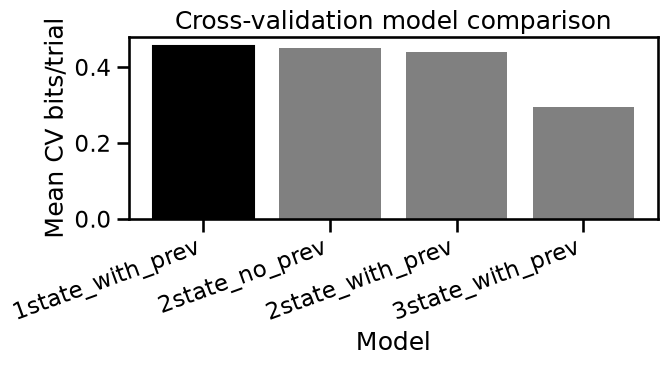

Winning model: 1state_with_prev
Mean CV bits/trial: 0.4559


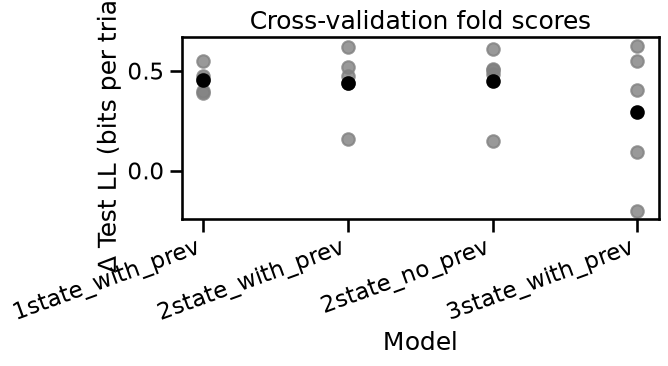

In [8]:
# bar chart of mean CV bits/trial per model
cv_plot_df = cv_summary.sort_values('mean_cv_bit_trial', ascending=False).copy()

plt.figure(figsize=(7, 4))
bars = plt.bar(cv_plot_df['model'], cv_plot_df['mean_cv_bit_trial'], color='gray')
bars[0].set_color('black')  # highlight winner
plt.ylabel('Mean CV bits/trial')
plt.xlabel('Model')
plt.title('Cross-validation model comparison')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

winning_model = cv_plot_df.iloc[0]['model']
winning_score = cv_plot_df.iloc[0]['mean_cv_bit_trial']
print(f'Winning model: {winning_model}')
print(f'Mean CV bits/trial: {winning_score:.4f}')

# CV fold-level scatter plot (works before best_specs is defined)
model_names = list(cv_bits_fold.keys())
plt.figure(figsize=(7, 4))
for idx, key_name in enumerate(model_names, start=1):
    fold_vals = np.asarray(cv_bits_fold[key_name])
    plt.scatter(np.full(len(fold_vals), idx), fold_vals, color='gray', alpha=0.8)
    plt.scatter(idx, fold_vals.mean(), color='black')
plt.xticks(range(1, len(model_names) + 1), model_names, rotation=20, ha='right')
plt.xlabel('Model')
plt.ylabel('Δ Test LL (bits per trial)')
plt.title('Cross-validation fold scores')
plt.tight_layout()
plt.show()

## 7) Fit the best model on all trials

Now we pick the HMM with the highest mean CV bits/trial and fit it on the full one-subject dataset.

**Task:** Inspect the log-probability trajectory for each initialization and check whether they converge similarly.

In [9]:
# fit the best HMM on all trials (ignore the GLM baseline here)
if 'model_type' not in cv_summary.columns:
    cv_summary = cv_summary.copy()
    cv_summary['model_type'] = cv_summary['model'].map(
        lambda m: model_variants_dict.get(m, {}).get('model_type', 'hmm')
    )

hmm_cv_summary = cv_summary[cv_summary['model_type'] == 'hmm'].copy()
best_model_name = hmm_cv_summary.sort_values('mean_cv_bit_trial', ascending=False).iloc[0]['model']
best_model_params = {k: v for k, v in model_variants_dict[best_model_name].items() if k != 'model_type'}
best_specs = set_HMM_params(HMM_default_specs, **best_model_params)

emission_prior_weights = (
    global_fit_params[best_model_name].emissions.weights,
    global_fit_params[best_model_name].emissions.biases,
 )

HMM_inits, HMM_params_inits, HMM_inits_lps = fit_HMM_dynamax(
    session_df,
    best_specs,
    emission_prior_weights,
    emission_prior_sigma=0.2,
    key=key,
 )

HMM_inits_final_ll = [lps[-1] for lps in HMM_inits_lps]
best_init_idx = np.argmax(HMM_inits_final_ll)
best_hmm = HMM_inits[best_init_idx]
best_params = HMM_params_inits[best_init_idx]

print('Best HMM model:', best_model_name)
print('Best init index:', best_init_idx)
print('Final log prob:', HMM_inits_final_ll[best_init_idx])

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:01&lt;00:00]</div>

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:01&lt;00:00]</div>

Best HMM model: 2state_no_prev
Best init index: 1
Final log prob: -155.13449


## 8) Inspect state probabilities

We relabel states using the stimulus-weight ordering, so we know that state 1 is the state where the participant has the highest sensitivity to the stimulus, then store state assignment and posterior probabilities in the dataframe.

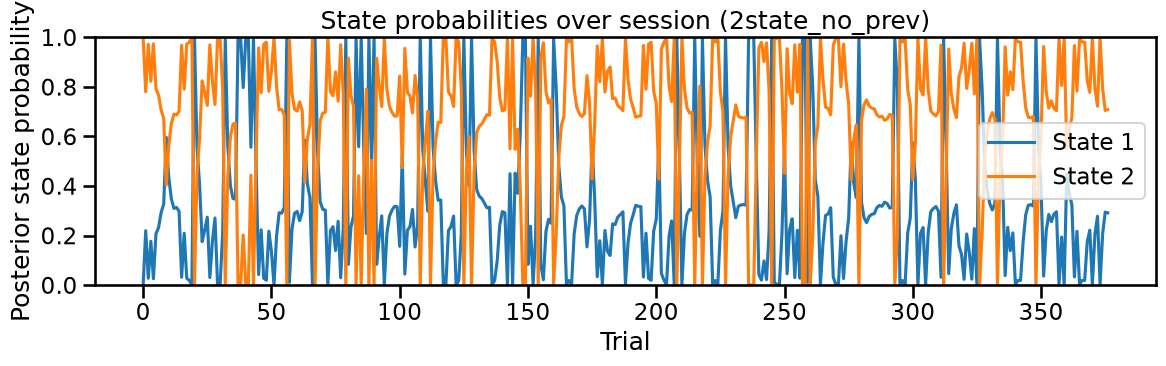

In [10]:
state_order = get_state_order_dynamax(best_params)
inferred_states = relabel_inferred_states_dynamax(best_hmm, best_params, session_df, best_specs)
session_df['inferred_state'] = inferred_states + 1

state_probs = get_state_probs_dynamax(best_hmm, best_params, session_df, best_specs)
for s in range(best_specs['n_states']):
    session_df[f'prob_state_{s}'] = state_probs[:, state_order[s]]

trial_idx = np.arange(len(session_df))
plt.figure(figsize=(12, 4))
for s in range(best_specs['n_states']):
    plt.plot(trial_idx, session_df[f'prob_state_{s}'], label=f'State {s + 1}')
plt.xlabel('Trial')
plt.ylabel('Posterior state probability')
plt.title(f'State probabilities over session ({best_model_name})')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 9) Visualization of state characteristics

**Task**: Think about the intepretation of each state - how are their parameters different? Is one state more 'sticky' or more dominant? 

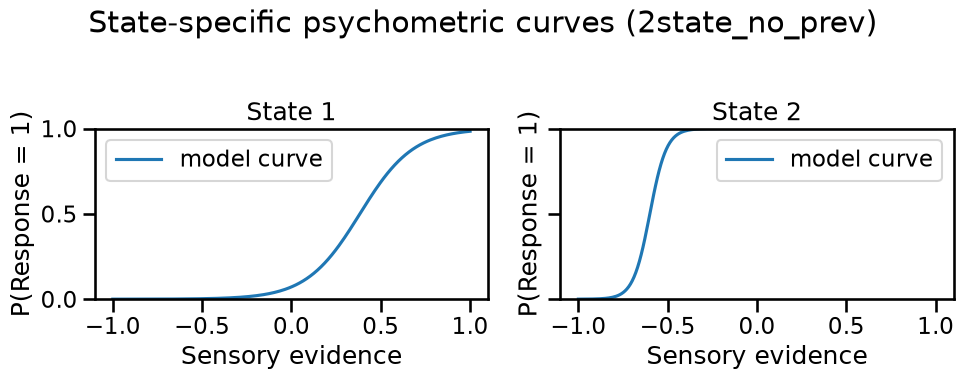

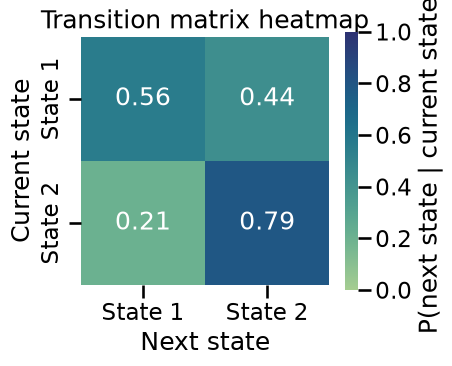

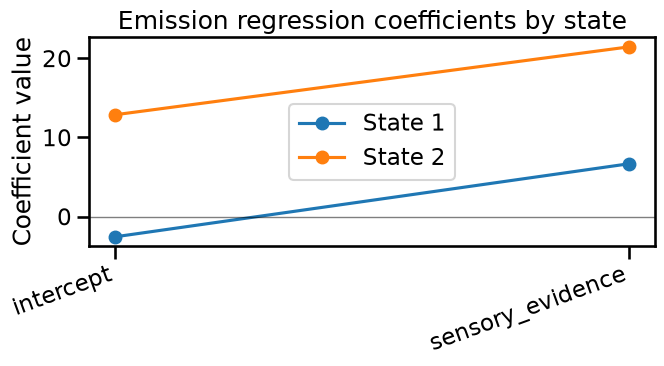

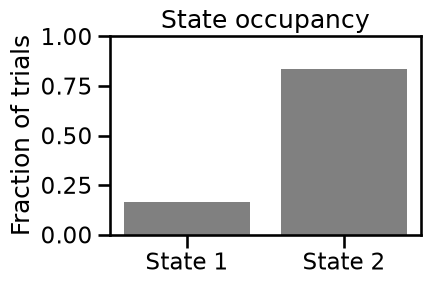

In [11]:
# state-specific psychometric curves - N.B. this is only implemented for sensory evidence and previous choice covariates, it will not work if you have added other covariates
plot_state_psychometric_curves(best_params, best_specs, session_df, best_model_name)

# transition matrix heatmap
_, transition_matrix = get_state_params_dynamax(best_params)
state_labels = [f'State {i + 1}' for i in range(transition_matrix.shape[0])]

plt.figure(figsize=(4.8, 4))
sns.heatmap(
    transition_matrix,
    annot=True,
    fmt='.2f',
    cmap='crest',
    vmin=0,
    vmax=1,
    square=True,
    xticklabels=state_labels,
    yticklabels=state_labels,
    cbar_kws={'label': 'P(next state | current state)'},
)
plt.xlabel('Next state')
plt.ylabel('Current state')
plt.title('Transition matrix heatmap')
plt.tight_layout()
plt.show()

# regression coefficients by state
betas, _ = get_state_params_dynamax(best_params)
coef_labels = ['intercept'] + best_specs['covariates_emissions']
x = np.arange(len(coef_labels))

plt.figure(figsize=(7, 4))
for s in range(betas.shape[0]):
    plt.plot(x, betas[s], marker='o', label=f'State {s + 1}')
plt.xticks(x, coef_labels, rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.ylabel('Coefficient value')
plt.title('Emission regression coefficients by state')
plt.legend()
plt.tight_layout()
plt.show()

# extra quick diagnostic: state occupancy
occupancy = session_df['inferred_state'].value_counts(normalize=True).sort_index()
plt.figure(figsize=(4.5, 3.2))
plt.bar([f'State {int(i)}' for i in occupancy.index], occupancy.values, color='gray')
plt.ylim(0, 1)
plt.ylabel('Fraction of trials')
plt.title('State occupancy')
plt.tight_layout()
plt.show()

## Possible exploratory questions

1. Is there a difference in RT across states?
2. Is there a difference in confidence across states?
3. What could cause state transitions? In the task, in the brain?
4. Do state occupancies change over the session (learning/fatigue effects)?
5. Are there differences across individuals?
.......